# Unemployment Analysis with Python

## Objective

This project performs exploratory data analysis on unemployment data from
India to identify regional and temporal trends and examine changes during
the COVID-19 period.

## Dataset

The analysis uses the **Unemployment in India** dataset, which contains
information about unemployment rate, estimated employment, labour
participation rate, region, date, frequency, and area.

## Analysis Performed

- Dataset inspection and data cleaning
- Missing-value analysis
- Descriptive statistics
- Region-wise average unemployment analysis
- Month-wise unemployment trends
- Time-series comparison of selected regions
- Top 10 regions by average unemployment rate
- Correlation analysis of employment indicators
- Pre-COVID vs COVID-19 period comparison
- Regional changes in unemployment during the COVID-19 period

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.shape

(768, 7)

In [5]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [7]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Display cleaned column names
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [8]:
# Check the number of missing values in each column
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [9]:
# Remove rows containing missing values
df = df.dropna()

# Check the new dataset size
df.shape

(740, 7)

In [10]:
# Convert Date from text to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Check the data type
df['Date'].dtype

dtype('<M8[ns]')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [12]:
# View summary statistics for numerical columns
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [13]:
# Check the number of unique regions
df['Region'].nunique()

28

In [14]:
# List all regions
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Chandigarh'],
      dtype=object)

## Region-wise Average Unemployment Rate

To understand how unemployment varies across different regions, we calculate
the average unemployment rate for each region.

In [16]:
# Calculate average unemployment rate for each region
region_avg_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values(ascending=False)
)

region_avg_unemployment

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

In [17]:
# Select the 10 regions with the highest average unemployment rate
top_10_regions = region_avg_unemployment.head(10)

top_10_regions

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

## Top 10 Regions by Average Unemployment Rate

The following bar chart shows the 10 regions with the highest average
unemployment rates in the dataset.

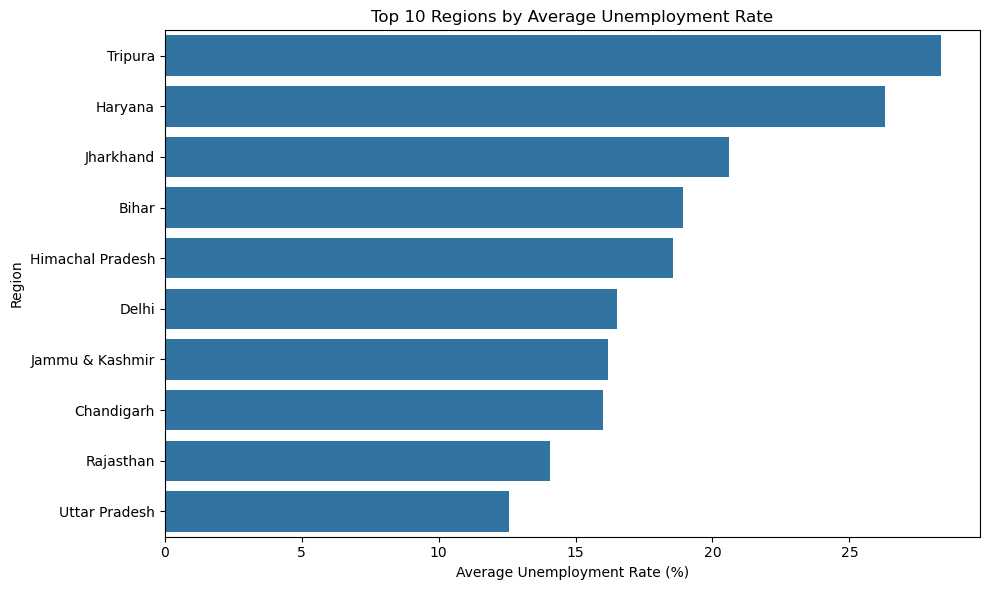

In [19]:
# Plot the top 10 regions with the highest average unemployment rate
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_regions.values,
    y=top_10_regions.index
)

plt.title('Top 10 Regions by Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

### Observation

Tripura recorded the highest average unemployment rate in the dataset at
approximately 28.35%, followed by Haryana at approximately 26.28%.
The results indicate considerable variation in average unemployment across
different regions.

## Month-wise Unemployment Trend

The line chart below shows the average unemployment rate across all regions
over time. The sharp increase during April and May 2020 highlights the
substantial rise in unemployment during the COVID-19 period.

In [22]:
# Calculate the average unemployment rate for each month
monthly_unemployment = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_index()
)

# Display the monthly averages
monthly_unemployment

Date
2019-05-31     8.874259
2019-06-30     9.303333
2019-07-31     9.033889
2019-08-31     9.637925
2019-09-30     9.051731
2019-10-31     9.900909
2019-11-30     9.868364
2019-12-31     9.497358
2020-01-31     9.950755
2020-02-29     9.964717
2020-03-31    10.700577
2020-04-30    23.641569
2020-05-31    24.875294
2020-06-30    11.903600
Name: Estimated Unemployment Rate (%), dtype: float64

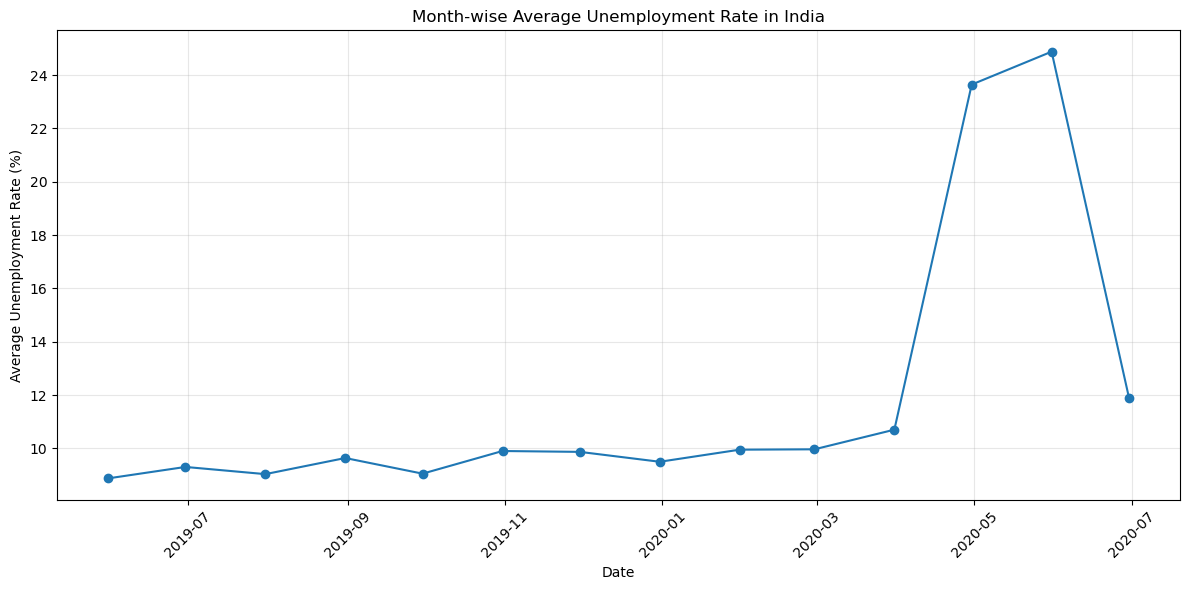

In [23]:
# Plot the month-wise average unemployment rate
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker='o'
)

plt.title('Month-wise Average Unemployment Rate in India')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

The average unemployment rate remained relatively stable during most of
2019 and early 2020. A sharp increase occurred during April and May 2020,
when the average unemployment rate reached approximately 23.64% and 24.88%,
respectively, before declining in June 2020.

## Unemployment Trends for Selected Regions

To compare regional unemployment patterns over time, the unemployment rates
of Tripura, Haryana, and Jharkhand are plotted together.

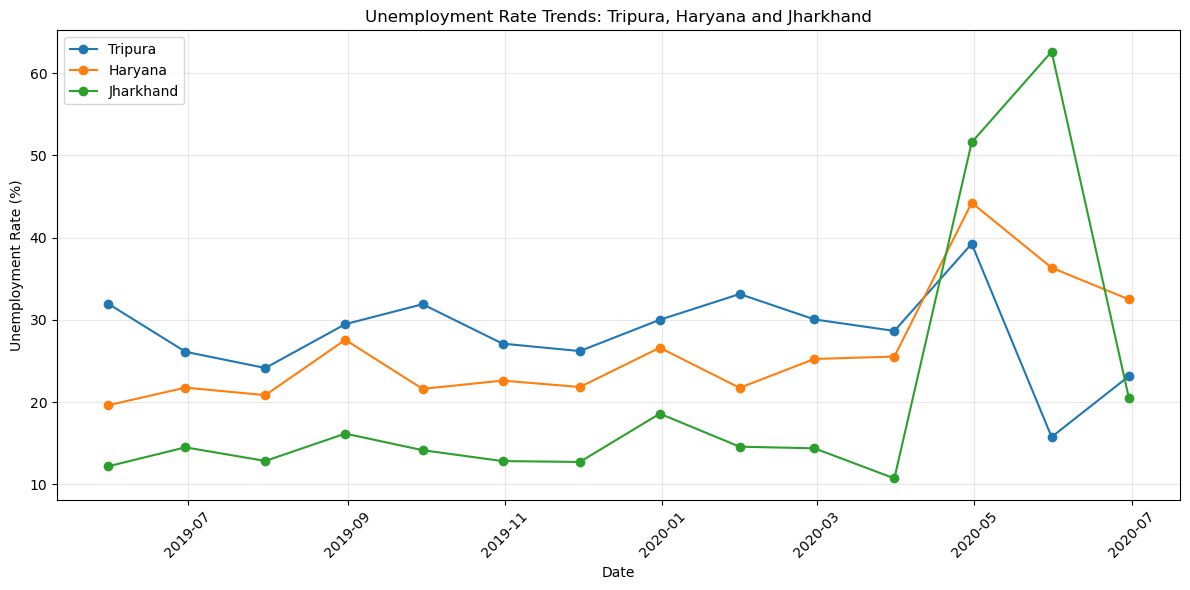

In [26]:
# Calculate average unemployment rate for each region and date
region_date_unemployment = (
    df.groupby(['Region', 'Date'])['Estimated Unemployment Rate (%)']
      .mean()
      .reset_index()
)

# Select three regions for comparison
selected_regions = ['Tripura', 'Haryana', 'Jharkhand']

plt.figure(figsize=(12, 6))

for region in selected_regions:
    region_data = region_date_unemployment[
        region_date_unemployment['Region'] == region
    ].sort_values('Date')
    
    plt.plot(
        region_data['Date'],
        region_data['Estimated Unemployment Rate (%)'],
        marker='o',
        label=region
    )

plt.title('Unemployment Rate Trends: Tripura, Haryana and Jharkhand')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

The selected regions show different unemployment patterns over time.
Unemployment increased sharply around the COVID-19 period, with Jharkhand
showing a particularly large increase compared with its earlier values.
Tripura and Haryana also experienced substantial increases.

## Correlation Between Employment Indicators

The correlation matrix examines the relationships among unemployment rate,
estimated employment, and labour participation rate.

The dataset provides an "Estimated Employed" measure rather than a separate
employment-rate column, so the analysis uses the available employment measure
directly.

In [29]:
# Select the employment-related numerical variables
correlation_data = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


## Correlation Heatmap

The heatmap visualizes the linear correlations among unemployment rate,
estimated employment, and labour participation rate.

The correlation between unemployment rate and estimated employment is weakly
negative, while the other relationships are close to zero.

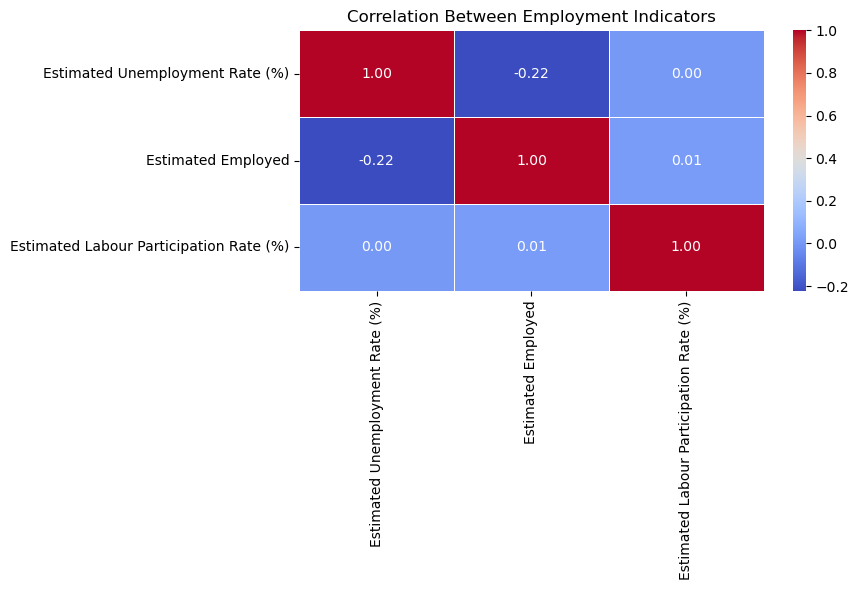

In [31]:
# Plot the correlation matrix
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Between Employment Indicators')
plt.tight_layout()
plt.show()

### Observation

The correlation between unemployment rate and estimated employment is
weakly negative (approximately -0.22). The correlations involving labour
participation rate are close to zero in this dataset, indicating little
linear association among these variables.

## Pre-COVID vs COVID-19 Period Unemployment Comparison

To examine changes in unemployment during the COVID-19 period, the dataset
is divided into pre-COVID and COVID-19 Period periods using March 2020 as the
starting point of the COVID-19 period.

In [34]:
# Define the COVID-19 period starting from March 2020
covid_start = pd.Timestamp('2020-03-01')

# Create a period column
df['Period'] = np.where(
    df['Date'] < covid_start,
    'Pre-COVID',
    'COVID-19 Period'
)

In [35]:
# Calculate average unemployment rate for each period
period_comparison = (
    df.groupby('Period')['Estimated Unemployment Rate (%)']
      .mean()
      .reindex(['Pre-COVID', 'COVID-19 Period'])
)

pre_covid = period_comparison['Pre-COVID']
covid_period = period_comparison['COVID-19 Period']

change = covid_period - pre_covid

print(f"Pre-COVID average unemployment rate: {pre_covid:.2f}%")
print(f"COVID-19 period average unemployment rate: {covid_period:.2f}%")
print(f"Change in unemployment rate: {change:.2f} percentage points")

Pre-COVID average unemployment rate: 9.51%
COVID-19 period average unemployment rate: 17.77%
Change in unemployment rate: 8.26 percentage points


## Pre-COVID vs COVID-19 Period Comparison

The bar chart compares the average unemployment rate before March 2020 with
the average unemployment rate from March 2020 onward.

The average unemployment rate increased from 9.51% in the pre-COVID period
to 17.77% during the COVID-19 period, an increase of 8.26 percentage points.

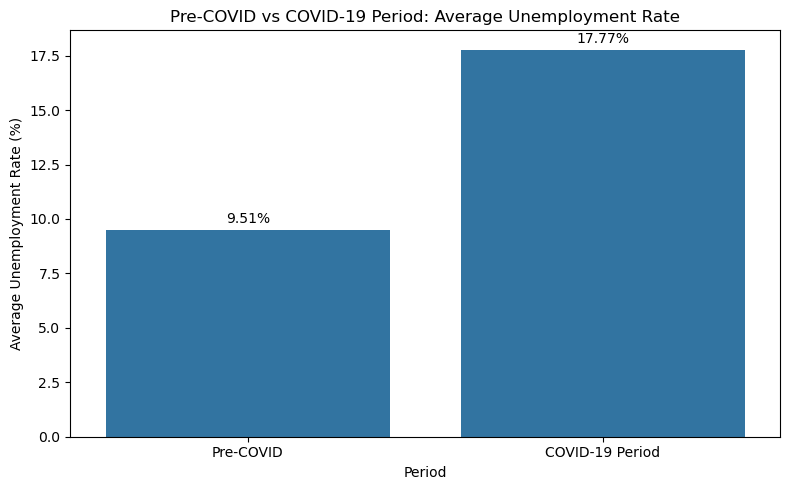

In [37]:
# Arrange periods in chronological order
period_comparison = period_comparison.reindex(
    ['Pre-COVID', 'COVID-19 Period']
)

# Create the comparison chart
plt.figure(figsize=(8, 5))

sns.barplot(
    x=period_comparison.index,
    y=period_comparison.values
)

plt.title('Pre-COVID vs COVID-19 Period: Average Unemployment Rate')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

# Add values above the bars
for i, value in enumerate(period_comparison.values):
    plt.text(i, value + 0.3, f'{value:.2f}%', ha='center')

plt.tight_layout()
plt.show()

### Observation

The average unemployment rate increased from 9.51% in the pre-COVID period
to 17.77% during the COVID-19 period, representing an increase of
approximately 8.26 percentage points.

## Regional Change in Unemployment During the COVID-19 Period

To understand whether the increase in unemployment was similar across
regions, we compare the average unemployment rate of each region before
March 2020 with its average rate from March 2020 onward.

In [40]:
# Calculate average unemployment by region and period
regional_period = (
    df.groupby(['Region', 'Period'])['Estimated Unemployment Rate (%)']
      .mean()
      .unstack()
)

# Calculate the change from the pre-COVID period to the COVID-19 period
regional_period['Change'] = (
    regional_period['COVID-19 Period'] - regional_period['Pre-COVID']
)

# Sort regions by the largest increase
regional_change = regional_period.sort_values(
    'Change',
    ascending=False
)

regional_change.head(10)

Period,COVID-19 Period,Pre-COVID,Change
Region,,,
Puducherry,38.95500,1.5930,37.36200
Tamil Nadu,25.40375,2.8365,22.56725
Jharkhand,36.34875,14.2795,22.06925
Bihar,31.63125,13.8330,17.79825
Karnataka,15.28000,3.2345,12.04550
Haryana,34.65250,22.9355,11.71700
Kerala,17.95250,6.9925,10.96000
Telangana,15.44250,4.6560,10.78650
Madhya Pradesh,14.07000,4.7410,9.32900


## Regions with the Largest Increase in Unemployment

The following chart shows the 10 regions with the largest increase in
average unemployment rate when comparing the pre-COVID period with the
COVID-19 period.

Puducherry recorded the largest increase among the regions in this dataset.

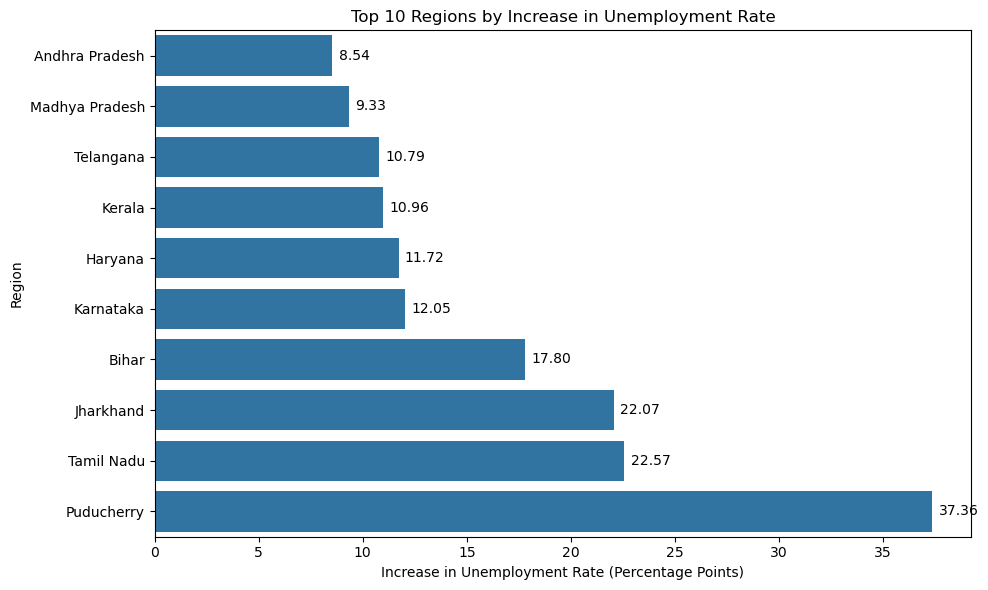

In [42]:
# Select the 10 regions with the largest increase
top_regional_changes = regional_change['Change'].head(10).sort_values()

# Plot the regional changes
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_regional_changes.values,
    y=top_regional_changes.index
)

plt.title('Top 10 Regions by Increase in Unemployment Rate')
plt.xlabel('Increase in Unemployment Rate (Percentage Points)')
plt.ylabel('Region')

# Add values to the bars
for i, value in enumerate(top_regional_changes.values):
    plt.text(value + 0.3, i, f'{value:.2f}', va='center')

plt.tight_layout()
plt.show()

### Observation

The increase in unemployment was not uniform across regions. Puducherry
recorded the largest increase at approximately 37.36 percentage points,
followed by Tamil Nadu and Jharkhand.

# Conclusion

The exploratory analysis reveals substantial regional and temporal variation
in unemployment across India.

The unemployment rate was relatively stable during much of 2019 and early
2020 but increased sharply during April and May 2020. The comparison between
the pre-COVID and COVID-19 periods shows an increase in average unemployment
from 9.51% to 17.77%, a rise of 8.26 percentage points.

Regional analysis also shows that the impact was not uniform. Puducherry,
Tamil Nadu, Jharkhand, and Bihar experienced some of the largest increases
in unemployment during the COVID-19 period.

The correlation analysis found a weak negative relationship between
unemployment and estimated employment, while the relationships involving
labour participation were close to zero.

Overall, the analysis highlights significant changes in unemployment across
both time and regions during the period covered by the dataset.